In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("../dataset/addiction_data.csv")

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

X = df.drop("Addiction_Level", axis=1)
y = df["Addiction_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [2]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2]]


c:\Users\123\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [4]:
import numpy as np

sample = np.array([[19, 8, 4, 2, 0]])  # example user

model.predict(sample)

c:\Users\123\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [5]:
import pickle
pickle.dump(model, open("../model/addiction_model.pkl", "wb"))

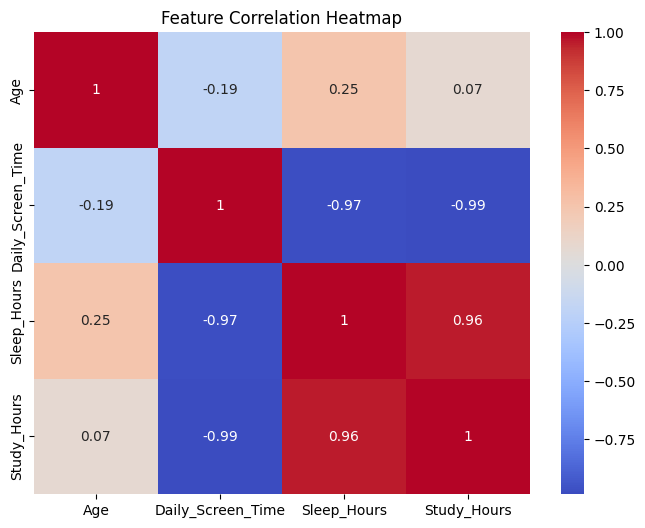

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset/addiction_data.csv")
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

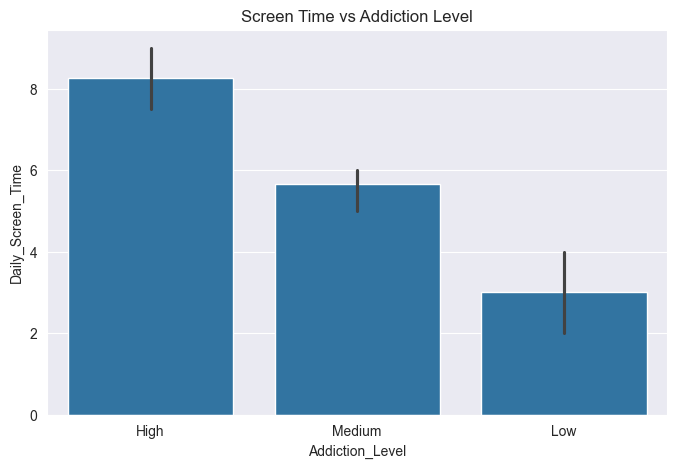

In [7]:
plt.figure(figsize=(8,5))
sns.set_style("darkgrid")
sns.barplot(x="Addiction_Level", y="Daily_Screen_Time", data=df)
plt.title("Screen Time vs Addiction Level")
plt.show()

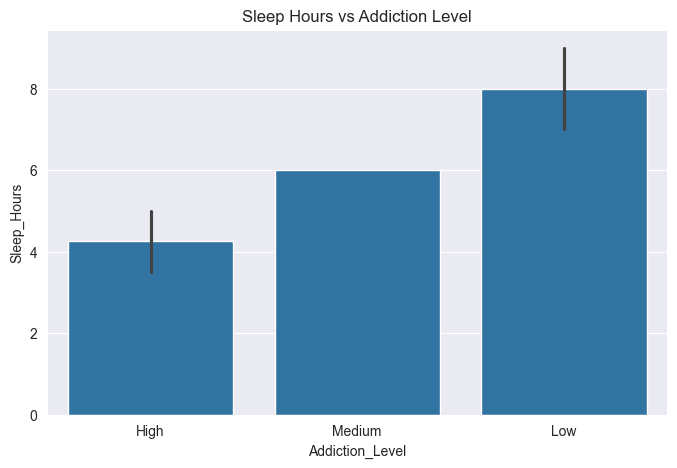

In [8]:
plt.figure(figsize=(8,5))
sns.set_style("darkgrid")
sns.barplot(x="Addiction_Level", y="Sleep_Hours", data=df)
plt.title("Sleep Hours vs Addiction Level")
plt.show()

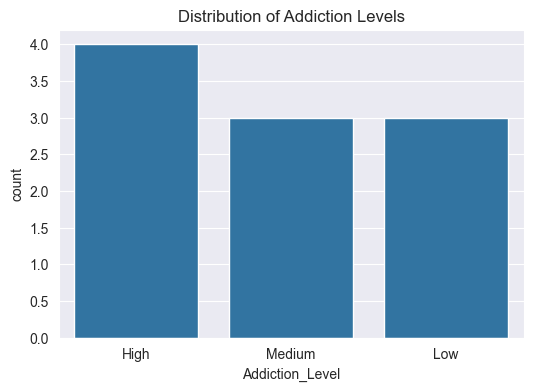

In [9]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")
sns.countplot(x="Addiction_Level", data=df)
plt.title("Distribution of Addiction Levels")
plt.show()

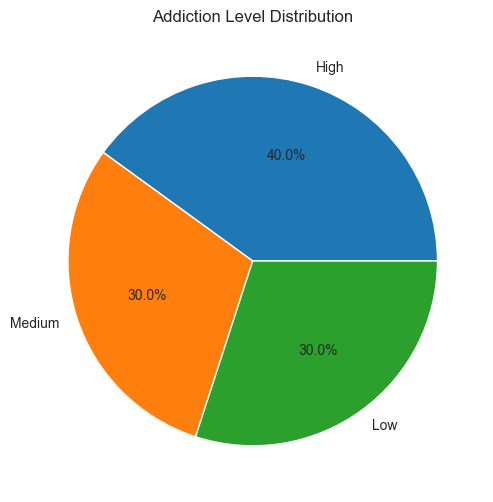

In [10]:
labels = df["Addiction_Level"].value_counts().index
sizes = df["Addiction_Level"].value_counts().values

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Addiction Level Distribution")
plt.show()

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.5


In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
pickle.dump(
    rf_model,
    open("../model/addiction_model.pkl", "wb")
)

print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 1.0


In [13]:
print("----- MODEL COMPARISON -----")
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

----- MODEL COMPARISON -----
Decision Tree Accuracy: 0.5
Random Forest Accuracy: 1.0


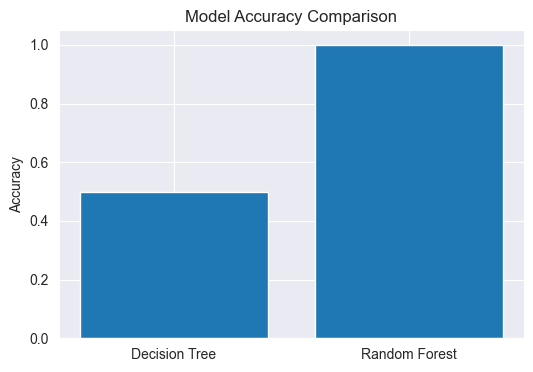

In [14]:
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest"]
accuracies = [dt_acc, rf_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()